# Preliminary Analysis on the Dataset

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

### Read dataframes

In [12]:
obama_tweets_df

,UserScreenName,UserName,Timestamp,Text,Embedded_text,Emojis,Comments,Likes,Retweets,Image link,Tweet URL,date
0,Barack Obama,@BarackObama,2007-05-07T15:52:28.000Z,"Barack Obama\n@BarackObama\n·\nMay 7, 2007",At the Detroit Economic Club – Talking about t...,NaN,22,29,105,[],https://twitter.com/BarackObama/status/53427172,2007-05-07 15:52:28+00:00
1,Barack Obama,@BarackObama,2007-05-08T21:01:32.000Z,"Barack Obama\n@BarackObama\n·\nMay 8, 2007",Thinking we can cut oil consumption by 2.5 mil...,NaN,27,14,36,[],https://twitter.com/BarackObama/status/55928192,2007-05-08 21:01:32+00:00
2,Barack Obama,@BarackObama,2007-05-11T01:15:18.000Z,"Barack Obama\n@BarackObama\n·\nMay 10, 2007","In Indianola, Iowa and heading to Des Moines\n...",NaN,25,19,73,[],https://twitter.com/BarackObama/status/59358952,2007-05-11 01:15:18+00:00
3,Barack Obama,@BarackObama,2007-05-16T19:47:37.000Z,"Barack Obama\n@BarackObama\n·\nMay 16, 2007",Thinking the President’s word is not the last ...,NaN,10,24,32,[],https://twitter.com/BarackObama/status/66208452,2007-05-16 19:47:37+00:00
4,Barack Obama,@BarackObama,2007-05-14T17:25:24.000Z,"Barack Obama\n@BarackObama\n·\nMay 14, 2007","In Trenton, NJ at AFL-CIO Town Hall Meeting\n8...",NaN,89,60,179,[],https://twitter.com/BarackObama/status/63909652,2007-05-14 17:25:24+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
11534,Barack Obama,@BarackObama,2022-06-16T21:31:32.000Z,Barack Obama\n@BarackObama\n·\nJun 16,We need to build democracy for the future—and ...,NaN,460,"1,131","6,763",[],https://twitter.com/BarackObama/status/1537548...,2022-06-16 21:31:32+00:00
11535,Barack Obama,@BarackObama,2022-06-15T16:00:37.000Z,Barack Obama\n@BarackObama\n·\nJun 15,"For the 10th anniversary of DACA, I met with t...",NaN,550,"1,233","6,957",['https://pbs.twimg.com/media/FVTifQnXsAEHvtE....,https://twitter.com/BarackObama/status/1537102...,2022-06-15 16:00:37+00:00
11536,Barack Obama,@BarackObama,2022-06-17T17:02:23.000Z,Barack Obama\n@BarackObama\n·\nJun 17,Congrats to \n@USMonastirBB\n for winning the ...,NaN,424,"1,752","9,161",['https://pbs.twimg.com/media/FVeEJ6hWAAA39gY?...,https://twitter.com/BarackObama/status/1537843...,2022-06-17 17:02:23+00:00
11537,Barack Obama,@BarackObama,2022-06-15T14:00:39.000Z,Barack Obama\n@BarackObama\n·\nJun 15,"For all they have done for our nation, and all...",NaN,386,"2,183",11.1K,['https://pbs.twimg.com/media/FVTFhspXoAAHCqp?...,https://twitter.com/BarackObama/status/1537072...,2022-06-15 14:00:39+00:00


In [37]:
tweets_df = pd.read_csv("data/trump_tweets.csv")

tweets_df['date'] = pd.to_datetime(tweets_df['date'])
tweets_df['isPresident'] = (tweets_df['date'].between(pd.to_datetime("2017-1-20"), pd.to_datetime("2021-1-20"))) | (tweets_df['date'] > pd.to_datetime("2025-1-20")) #YMD format

tweets_df = tweets_df.sort_values(by="date")

# ---------------------------------------------------------------

obama_tweets_df = pd.read_csv('data/obama.csv')
obama_tweets_df['date'] = pd.to_datetime(obama_tweets_df['Timestamp']).dt.tz_localize(None)
obama_tweets_df['isPresident'] = (obama_tweets_df['date'].between(pd.to_datetime("2009-1-20"), pd.to_datetime("2017-1-20"))) #YMD format

obama_tweets_df = obama_tweets_df.sort_values(by="date")
obama_tweets_df.drop('Emojis', axis=1, inplace=True)

# ---------------------------------------------------------------

vix_df = pd.read_csv("data/VIX_DAILY.csv")
vix_df["observation_date"] = pd.to_datetime(vix_df["observation_date"])
vix_df = vix_df.sort_values("observation_date")

merged = pd.merge_asof(tweets_df, vix_df, left_on="date", right_on="observation_date", direction='backward')
merged.dropna(inplace=True)
merged_bama = pd.merge_asof(obama_tweets_df, vix_df, left_on="date", right_on="observation_date", direction='backward')
merged_bama.dropna(inplace=True)

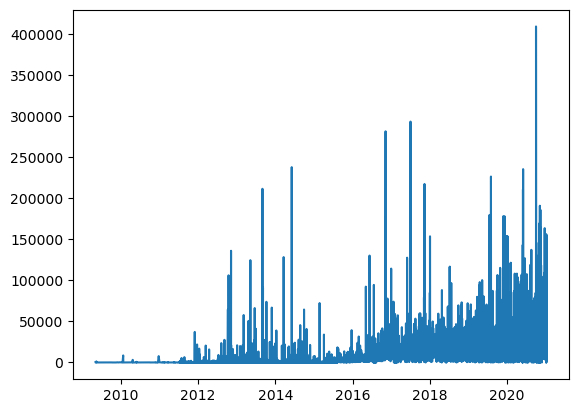

In [3]:
plt.plot(tweets_df['date'], tweets_df['retweets'])
plt.show()
plt.close()

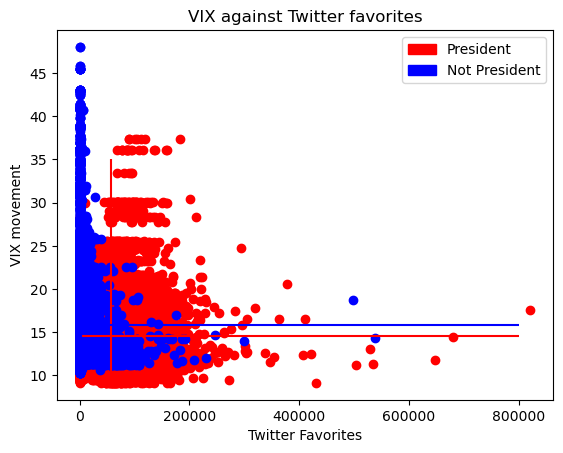

In [45]:
plt.figure()
for p in ["red", "blue"]:
    plt.scatter(merged['favorites'][merged["isPresident"] == (p == "red")], merged['VIXCLS'][merged["isPresident"] == (p == "red")], c=p) # red if president
    

for p in ["red", "blue"]:
    plt.vlines(np.mean(merged['favorites'][merged["isPresident"] == (p == "red")]), ymin=10, ymax=35, colors=p)
    plt.hlines(np.mean(merged['VIXCLS'][merged["isPresident"] == (p == "red")]), xmin=0, xmax=800_000, colors=p)
    
p_patch = mpatches.Patch(color="red", label="President")
np_patch = mpatches.Patch(color="blue", label="Not President")

plt.legend(handles=[p_patch, np_patch])    

plt.title("VIX against Twitter favorites")
plt.xlabel("Twitter Favorites")
plt.ylabel("VIX movement")
plt.show()
plt.close()

In [43]:

def convert_shorthands(num):
    num = num.replace(',','')
    if 'k' in num.lower():
        return float(num.lower().replace('k','')) * 1_000
    if 'm' in num.lower():
        return float(num.lower().replace('m','')) * 1_000_000
    return float(num)

merged_bama['Likes'] = merged_bama['Likes'].apply(convert_shorthands)

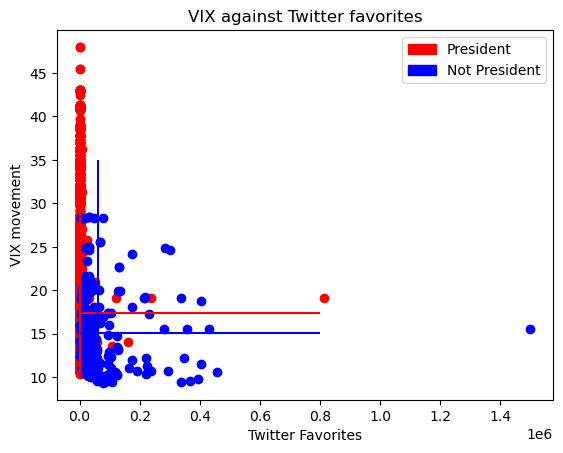

In [44]:
plt.figure()
for p in ["red", "blue"]:
    plt.scatter(merged_bama['Likes'][merged_bama["isPresident"] == (p == "red")], merged_bama['VIXCLS'][merged_bama["isPresident"] == (p == "red")], c=p) # red if president
    

for p in ["red", "blue"]:
    plt.vlines(np.mean(merged_bama['Likes'][merged_bama["isPresident"] == (p == "red")]), ymin=10, ymax=35, colors=p)
    plt.hlines(np.mean(merged_bama['VIXCLS'][merged_bama["isPresident"] == (p == "red")]), xmin=0, xmax=800_000, colors=p)
    
p_patch = mpatches.Patch(color="red", label="President")
np_patch = mpatches.Patch(color="blue", label="Not President")

plt.legend(handles=[p_patch, np_patch])    

plt.title("VIX against Twitter favorites")
plt.xlabel("Twitter Favorites")
plt.ylabel("VIX movement")
plt.show()
plt.close()

## Analysis

### Imports

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
X = merged['text']
y = merged['VIXCLS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

vectorizer = TfidfVectorizer(lowercase=True, stop_words='english') # Handles tokenization internally
X_train_vectorized = vectorizer.fit_transform(X_train)

# Train a Linear Regression model
model = Ridge(alpha=0.8)
model.fit(X_train_vectorized, y_train)

# 3. Make predictions on the test set
X_test_vectorized = vectorizer.transform(X_test)
y_pred = model.predict(X_test_vectorized)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))

MSE: 13.67789924821801
R^2: 0.1625372481547015


In [ ]:
X = merged['text'][merged["isPresident"]]
y = merged['VIXCLS'][merged["isPresident"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

vectorizer = TfidfVectorizer(lowercase=True, stop_words='english') # Handles tokenization internally
X_train_vectorized = vectorizer.fit_transform(X_train)

# Train a Linear Regression model
model = Ridge(alpha=0.8)
model.fit(X_train_vectorized, y_train)

# 3. Make predictions on the test set
X_test_vectorized = vectorizer.transform(X_test)
y_pred = model.predict(X_test_vectorized)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))
print("Intercept:", model.intercept_)

MSE: 12.481399605474625
R^2: 0.08036307644972052
InterceptL 13.867633775873658


In [ ]:
X = merged['text'][~merged["isPresident"]]
y = merged['VIXCLS'][~merged["isPresident"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

vectorizer = TfidfVectorizer(lowercase=True, stop_words='english') # Handles tokenization internally
X_train_vectorized = vectorizer.fit_transform(X_train)

# Train a Linear Regression model
model = Ridge(alpha=0.8)
model.fit(X_train_vectorized, y_train)

# 3. Make predictions on the test set
X_test_vectorized = vectorizer.transform(X_test)
y_pred = model.predict(X_test_vectorized)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))
print("Intercept:", model.intercept_)

MSE: 14.623994587105619
R^2: 0.17755339928573877
InterceptL 15.723314613103014
